
# Flow Matching (1D/2D) vs Diffusion Model on Gaussian Mixtures

**Goal:** Implement a minimal **Flow Matching (FM)** model on **1D & 2D Gaussian Mixtures**,  
and compare with a simple **Diffusion Model (DDPM-style)** baseline.

We will:
1. Generate 1D and 2D Gaussian mixtures.
2. Train **Flow Matching** (deterministic, linear interpolant) on both datasets.
3. Train a **Diffusion** model (predicting noise) on the same datasets.
4. Evaluate with **Sliced Wasserstein Distance (SWD)** and visualize samples.



## 1. Environment


In [1]:

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
torch.manual_seed(42)



## 2. Data Generators (1D & 2D GMM)


In [2]:

def make_gmm_1d(n=4000, means=None, stds=None, probs=None, seed=0):
    rng = np.random.default_rng(seed)
    if means is None:
        means = np.array([-2.0, 0.0, 2.5], dtype=np.float32)
    if stds is None:
        stds = np.array([0.4, 0.6, 0.5], dtype=np.float32)
    k = len(means)
    if probs is None:
        probs = np.ones(k) / k
    comps = rng.choice(k, size=n, p=probs)
    x = rng.normal(means[comps], stds[comps]).astype(np.float32)
    return x.reshape(-1,1)

def make_gmm_2d(n=4000, centers=None, covs=None, probs=None, seed=0):
    rng = np.random.default_rng(seed)
    if centers is None:
        centers = [np.array([0.0, 0.0]), np.array([2.5, 2.5]), np.array([-2.5, 2.5])]
    if covs is None:
        covs = [np.array([[0.3, 0.0],[0.0, 0.3]]),
                np.array([[0.4, 0.1],[0.1, 0.3]]),
                np.array([[0.3, -0.05],[-0.05, 0.4]])]
    k = len(centers)
    if probs is None:
        probs = np.ones(k) / k
    comps = rng.choice(k, size=n, p=probs)
    data = np.zeros((n, 2), dtype=np.float32)
    for i, c in enumerate(comps):
        data[i] = rng.multivariate_normal(centers[c], covs[c]).astype(np.float32)
    return data

def train_test_split(X, n_train=3000, seed=123):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    tr = idx[:n_train]
    te = idx[n_train:]
    return X[tr], X[te]



## 3. Metric: Sliced Wasserstein Distance (SWD)


In [3]:

def sliced_wasserstein_distance(X, Y, n_projections=256, seed=0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    assert X.shape[1] == Y.shape[1]
    d = X.shape[1]
    n = min(len(X), len(Y))
    X = X[:n]; Y = Y[:n]
    if d == 1:
        x_sorted = np.sort(X[:,0])
        y_sorted = np.sort(Y[:,0])
        return float(np.mean((x_sorted - y_sorted)**2))**0.5
    dist = 0.0
    for _ in range(n_projections):
        v = rng.normal(size=(d,)).astype(np.float32)
        v /= np.linalg.norm(v) + 1e-8
        x_proj = np.dot(X, v)
        y_proj = np.dot(Y, v)
        x_sorted = np.sort(x_proj)
        y_sorted = np.sort(y_proj)
        dist += np.mean((x_sorted - y_sorted)**2)**0.5
    return dist / n_projections



## 4. Flow Matching (deterministic, linear interpolant)


In [4]:

class TimeEmbedding(nn.Module):
    def __init__(self, n_features=32, max_freq=10.0):
        super().__init__()
        self.n = n_features
        self.freqs = nn.Parameter(torch.linspace(1.0, max_freq, n_features), requires_grad=False)
    def forward(self, t):
        wt = t * self.freqs[None,:]
        return torch.cat([torch.sin(wt), torch.cos(wt)], dim=-1)

class VelocityNet(nn.Module):
    def __init__(self, dim, hidden=128, tfeat=32):
        super().__init__()
        self.time_emb = TimeEmbedding(n_features=tfeat)
        self.net = nn.Sequential(
            nn.Linear(dim + 2*tfeat, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim)
        )
    def forward(self, x, t):
        te = self.time_emb(t)
        return self.net(torch.cat([x, te], dim=-1))

def train_flow_matching(X, dim, epochs=800, batch_size=512, lr=1e-3, verbose_every=200):
    X = torch.from_numpy(X).float().to(device)
    ds = TensorDataset(X)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = VelocityNet(dim=dim).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for ep in range(1, epochs+1):
        epoch_loss = 0.0
        for (x1,) in dl:
            b = x1.size(0)
            x0 = torch.randn_like(x1)
            t = torch.rand(b, 1, device=x1.device)
            xt = (1.0 - t) * x0 + t * x1
            v_target = x1 - x0
            v_pred = model(xt, t)
            loss = ((v_pred - v_target)**2).mean()
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            epoch_loss += loss.item() * b
        epoch_loss /= len(ds)
        losses.append(epoch_loss)
        if verbose_every and ep % verbose_every == 0:
            print(f"[FM] Epoch {ep:04d} | Loss: {epoch_loss:.4f}")
    return model, losses

@torch.no_grad()
def flow_matching_sample(model, n, dim, n_steps=200):
    x = torch.randn(n, dim, device=device)
    t = torch.zeros(n, 1, device=device)
    dt = 1.0 / n_steps
    for _ in range(n_steps):
        v = model(x, t)
        x = x + dt * v
        t = t + dt
    return x.detach().cpu().numpy()



## 5. Diffusion (DDPM-style)


In [5]:

class NoiseNet(nn.Module):
    def __init__(self, dim, hidden=128, tfeat=32):
        super().__init__()
        self.time_emb = TimeEmbedding(n_features=tfeat)
        self.net = nn.Sequential(
            nn.Linear(dim + 2*tfeat, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim)
        )
    def forward(self, x, t):
        te = self.time_emb(t)
        return self.net(torch.cat([x, te], dim=-1))

def make_beta_schedule(T=200, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def precompute_alpha(beta):
    alpha = 1.0 - beta
    abar = torch.cumprod(alpha, dim=0)
    return alpha, abar

def train_diffusion(X, dim, epochs=800, batch_size=512, lr=1e-3, T=200, verbose_every=200):
    X = torch.from_numpy(X).float().to(device)
    ds = TensorDataset(X)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    beta = make_beta_schedule(T).to(device)
    alpha, abar = precompute_alpha(beta)
    model = NoiseNet(dim=dim).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for ep in range(1, epochs+1):
        epoch_loss = 0.0
        for (x0,) in dl:
            b = x0.size(0)
            t_idx = torch.randint(0, T, (b,), device=device)
            abar_t = abar[t_idx].view(-1,1)
            eps = torch.randn_like(x0)
            xt = torch.sqrt(abar_t) * x0 + torch.sqrt(1.0 - abar_t) * eps
            t_cont = (t_idx.float() / (T-1)).view(-1,1)
            eps_pred = model(xt, t_cont)
            loss = ((eps_pred - eps)**2).mean()
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            epoch_loss += loss.item() * b
        epoch_loss /= len(ds)
        losses.append(epoch_loss)
        if verbose_every and ep % verbose_every == 0:
            print(f"[DDPM] Epoch {ep:04d} | Loss: {epoch_loss:.4f}")
    return model, losses, beta, alpha, abar

@torch.no_grad()
def diffusion_sample(model, n, dim, beta, alpha, abar):
    T = len(beta)
    x = torch.randn(n, dim, device=device)
    for t in reversed(range(T)):
        t_cont = torch.full((n,1), float(t)/(T-1), device=device)
        eps = model(x, t_cont)
        a = alpha[t]
        ab = abar[t]
        if t > 0:
            z = torch.randn_like(x)
            beta_t = beta[t]
            mean = (1.0 / torch.sqrt(a)) * (x - (1 - a) / torch.sqrt(1.0 - ab + 1e-8) * eps)
            var = beta_t
            x = mean + torch.sqrt(var) * z
        else:
            x = (x - torch.sqrt(1.0 - ab) * eps) / torch.sqrt(ab + 1e-8)
    return x.detach().cpu().numpy()



## 6. 1D Experiment


[FM] Epoch 0100 | Loss: 2.3425
[FM] Epoch 0200 | Loss: 2.4279
[FM] Epoch 0300 | Loss: 2.4813
[FM] Epoch 0400 | Loss: 2.3890
[FM] Epoch 0500 | Loss: 2.4273


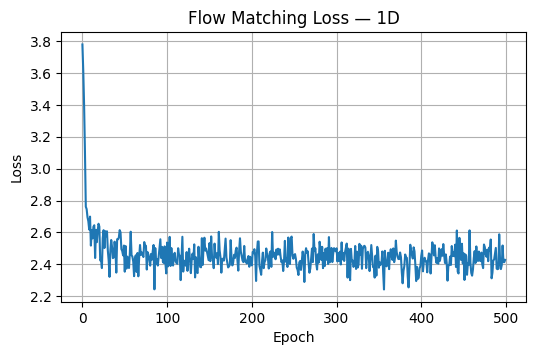

[1D] FM SWD: 0.1377
[DDPM] Epoch 0100 | Loss: 0.6364
[DDPM] Epoch 0200 | Loss: 0.6101
[DDPM] Epoch 0300 | Loss: 0.6151
[DDPM] Epoch 0400 | Loss: 0.5874
[DDPM] Epoch 0500 | Loss: 0.5686


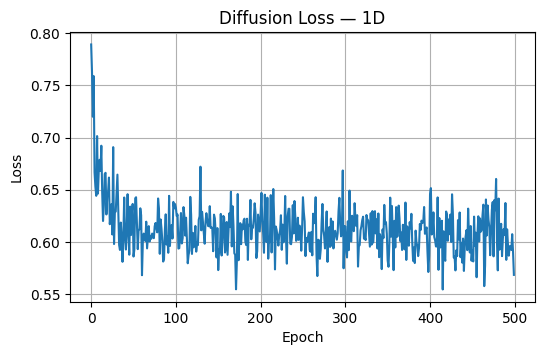

[1D] DDPM SWD: 0.2223


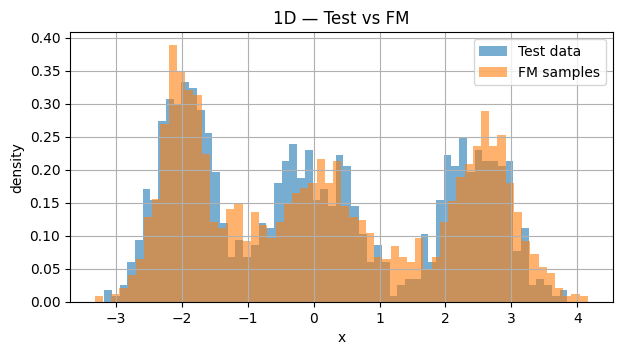

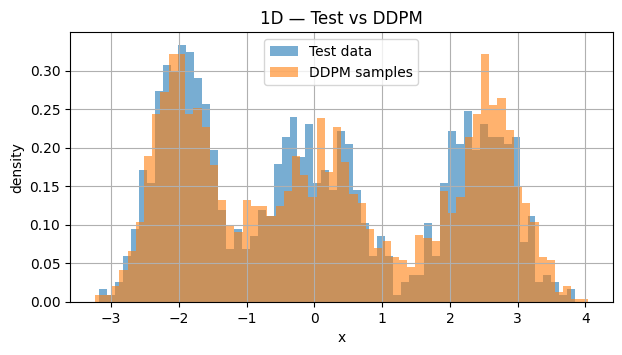

In [6]:

X1d = make_gmm_1d(n=4000, seed=11)
X1d_tr, X1d_te = train_test_split(X1d, n_train=3000, seed=11)

# Flow Matching
fm1d, fm1d_losses = train_flow_matching(X1d_tr, dim=1, epochs=500, batch_size=512, lr=1e-3, verbose_every=100)
plt.figure(figsize=(6,3.5)); plt.plot(fm1d_losses); plt.title("Flow Matching Loss — 1D"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
fm1d_samples = flow_matching_sample(fm1d, n=2000, dim=1, n_steps=200)
swd_fm_1d = sliced_wasserstein_distance(fm1d_samples, X1d_te, n_projections=1, seed=0)
print(f"[1D] FM SWD: {swd_fm_1d:.4f}")

# Diffusion
ddpm1d, ddpm1d_losses, beta1d, alpha1d, abar1d = train_diffusion(X1d_tr, dim=1, epochs=500, batch_size=512, lr=1e-3, T=200, verbose_every=100)
plt.figure(figsize=(6,3.5)); plt.plot(ddpm1d_losses); plt.title("Diffusion Loss — 1D"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
ddpm1d_samples = diffusion_sample(ddpm1d, n=2000, dim=1, beta=beta1d, alpha=alpha1d, abar=abar1d)
swd_ddpm_1d = sliced_wasserstein_distance(ddpm1d_samples, X1d_te, n_projections=1, seed=0)
print(f"[1D] DDPM SWD: {swd_ddpm_1d:.4f}")

# Plots
plt.figure(figsize=(7,3.5))
plt.hist(X1d_te.reshape(-1), bins=60, density=True, alpha=0.6, label="Test data")
plt.hist(fm1d_samples.reshape(-1), bins=60, density=True, alpha=0.6, label="FM samples")
plt.title("1D — Test vs FM"); plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,3.5))
plt.hist(X1d_te.reshape(-1), bins=60, density=True, alpha=0.6, label="Test data")
plt.hist(ddpm1d_samples.reshape(-1), bins=60, density=True, alpha=0.6, label="DDPM samples")
plt.title("1D — Test vs DDPM"); plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.grid(True); plt.show()



## 7. 2D Experiment


[FM] Epoch 0150 | Loss: 2.0014
[FM] Epoch 0300 | Loss: 2.0116
[FM] Epoch 0450 | Loss: 1.9963
[FM] Epoch 0600 | Loss: 1.9615


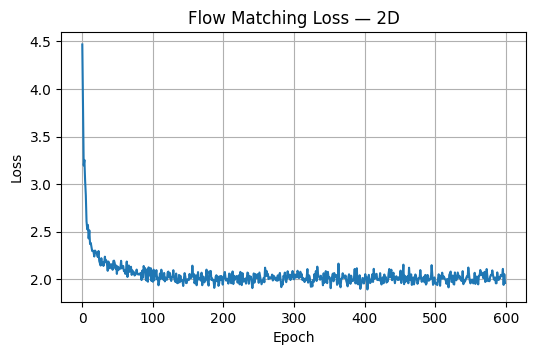

[2D] FM SWD: 0.1936
[DDPM] Epoch 0150 | Loss: 0.4352
[DDPM] Epoch 0300 | Loss: 0.4533
[DDPM] Epoch 0450 | Loss: 0.4493
[DDPM] Epoch 0600 | Loss: 0.4413


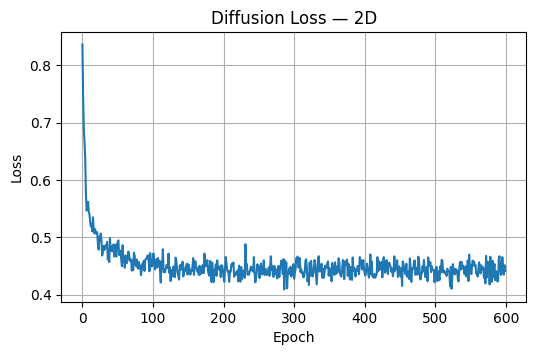

[2D] DDPM SWD: 0.2539


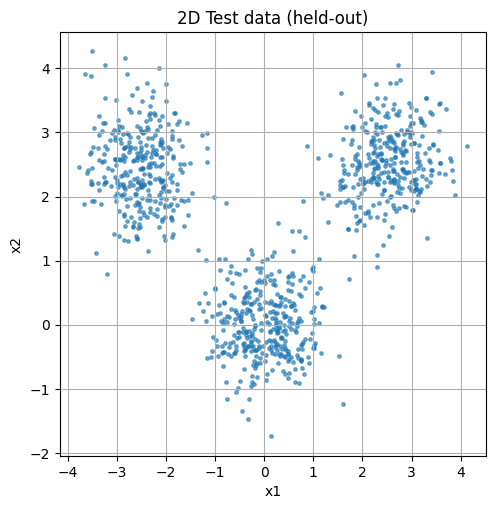

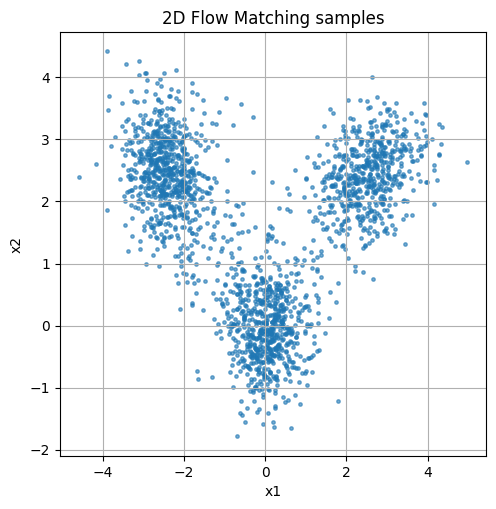

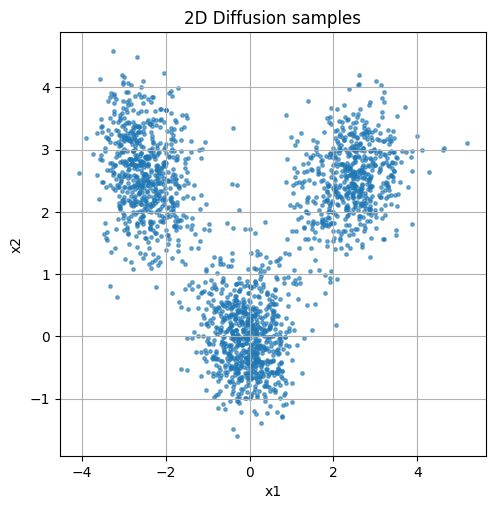

In [7]:

X2d = make_gmm_2d(n=4000, seed=22)
X2d_tr, X2d_te = train_test_split(X2d, n_train=3000, seed=22)

# Flow Matching
fm2d, fm2d_losses = train_flow_matching(X2d_tr, dim=2, epochs=600, batch_size=512, lr=1e-3, verbose_every=150)
plt.figure(figsize=(6,3.5)); plt.plot(fm2d_losses); plt.title("Flow Matching Loss — 2D"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
fm2d_samples = flow_matching_sample(fm2d, n=2000, dim=2, n_steps=300)
swd_fm_2d = sliced_wasserstein_distance(fm2d_samples, X2d_te, n_projections=256, seed=0)
print(f"[2D] FM SWD: {swd_fm_2d:.4f}")

# Diffusion
ddpm2d, ddpm2d_losses, beta2d, alpha2d, abar2d = train_diffusion(X2d_tr, dim=2, epochs=600, batch_size=512, lr=1e-3, T=300, verbose_every=150)
plt.figure(figsize=(6,3.5)); plt.plot(ddpm2d_losses); plt.title("Diffusion Loss — 2D"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
ddpm2d_samples = diffusion_sample(ddpm2d, n=2000, dim=2, beta=beta2d, alpha=alpha2d, abar=abar2d)
swd_ddpm_2d = sliced_wasserstein_distance(ddpm2d_samples, X2d_te, n_projections=256, seed=0)
print(f"[2D] DDPM SWD: {swd_ddpm_2d:.4f}")

# Visuals
def plot_scatter(X, title):
    plt.figure(figsize=(5.5,5.5))
    plt.scatter(X[:,0], X[:,1], s=6, alpha=0.6)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2"); plt.grid(True)
    plt.show()

plot_scatter(X2d_te, "2D Test data (held-out)")
plot_scatter(fm2d_samples, "2D Flow Matching samples")
plot_scatter(ddpm2d_samples, "2D Diffusion samples")
